In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

images_dir = os.path.join('..', 'data', 'milk10k', 'images')

if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Directory not found: {images_dir}. Ensure you are running this from inside the 'notebooks' folder.")

# Gather all images in the folder
all_images = sorted([f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

if len(all_images) == 0:
    raise FileNotFoundError(f"No image files found in {images_dir}")

target_name = 'ISIC_0024306.jpg'
selected_file = target_name if target_name in all_images else all_images[0]
img_path = os.path.join(images_dir, selected_file)

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError(f"OpenCV failed to load image at {img_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"Primary Image Loaded: {selected_file}")

Primary Image Loaded: ISIC_0051817.jpg



=== 1. PIXELS & RESOLUTION ===
Spatial Resolution: 450 x 600
NumPy Array Shape: (450, 600, 3)
Data Type (dtype): uint8


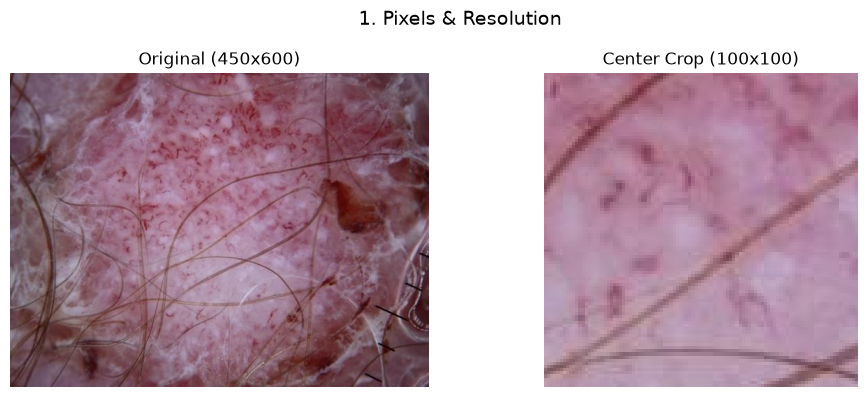

In [ ]:
height, width, channels = img.shape
print("\n=== 1. PIXELS & RESOLUTION ===")
print(f"Spatial Resolution: {height} x {width}")
print(f"NumPy Array Shape: {img.shape}")
print(f"Data Type (dtype): {img.dtype}")

# 100x100 Center Crop
center_y, center_x = height // 2, width // 2
crop_h, crop_w = 100, 100
start_y, end_y = center_y - (crop_h // 2), center_y + (crop_h // 2)
start_x, end_x = center_x - (crop_w // 2), center_x + (crop_w // 2)
cropped_img = img[start_y:end_y, start_x:end_x]


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title(f"Original ({height}x{width})")
axes[0].axis('off')

axes[1].imshow(cropped_img)
axes[1].set_title("Center Crop (100x100)")
axes[1].axis('off')
plt.suptitle("1. Pixels & Resolution", fontsize=14)
plt.tight_layout()
plt.show()

Spatial resolution is described as 450x600, which means there are 270,000 distinct pixels (450 rows and 600 columns). A high spatial resolution means that the size of each pixel is smaller with respect to the tissue area, meaning that the finer details of the tissue structure can be captured. 

The tensor shape is (450,600,3) because it is a three-dimensional tensor. The shape has three numbers because there are three dimensions: the first two numbers define the height and weight of the image, and the last number represents the three color channels, namely red, green, and blue (RGB image). 

The uint8 refers to the 8-bit unsigned integer format, which representats that every pixel has a value ranging from 0 (black) to 255 (white). 
The cropping to 100x100 area misses the complete border of the lesion. This makes clinical diagnosis much harder because it lacks essential information.

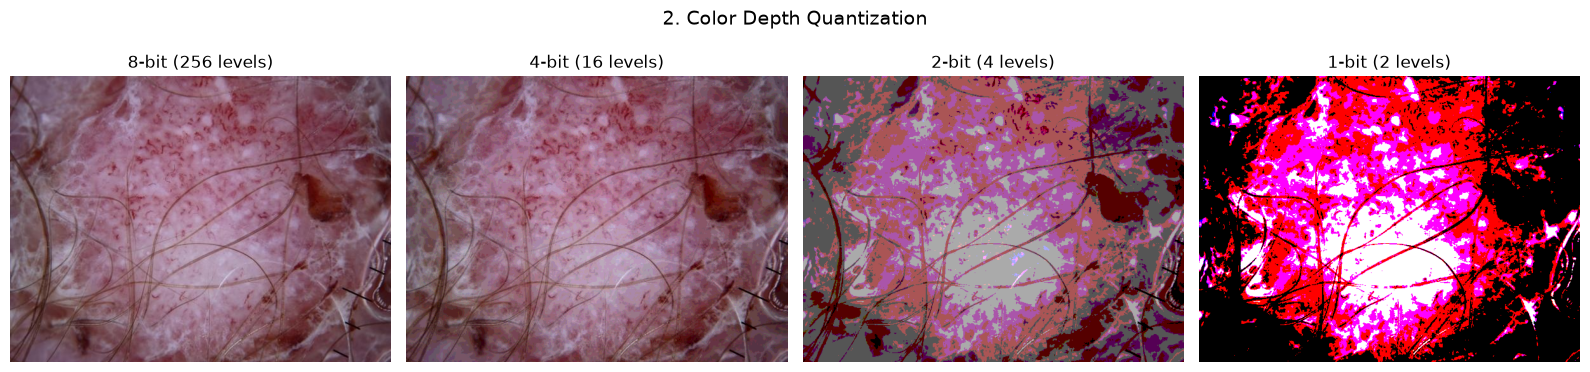

In [6]:
def quantize_bits(image, bits):
    levels = 2 ** bits
    quantized = np.floor(image / 256.0 * levels) * (255.0 / (levels - 1))
    return quantized.astype(np.uint8)

img_8bit = img
img_4bit = quantize_bits(img, 4)  # 16 levels
img_2bit = quantize_bits(img, 2)  # 4 levels
img_1bit = quantize_bits(img, 1)  # 2 levels (pure B/W)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_8bit); axes[0].set_title("8-bit (256 levels)"); axes[0].axis('off')
axes[1].imshow(img_4bit); axes[1].set_title("4-bit (16 levels)");  axes[1].axis('off')
axes[2].imshow(img_2bit); axes[2].set_title("2-bit (4 levels)");   axes[2].axis('off')
axes[3].imshow(img_1bit); axes[3].set_title("1-bit (2 levels)");   axes[3].axis('off')
plt.suptitle("2. Color Depth Quantization", fontsize=14)
plt.tight_layout()
plt.show()

It is difficult to discern the lesion boundary at 2-bit levels and is mostly distorted or truncated at 1-bit levels.
8-bit and 4-bit levels have a strong contrast even in the middle of the lesion and also show nice transitions of colors.
With the 2-bit level of image detail, the image reveals coarse blocks of colors, which makes the actual border very jagged, chopped off, and mixed with additional artifacts.
At the 1-bit level the border of the lesion is binary and very broad, eliminating some nuances of the tonal areas completely, making them go into uniform bright or dark areas.
Quantization makes it really complicated to see border details and distorts the real jaggedness of the image.
The significant reduction of color depth leads to the disappearance of the nuances in colors and makes it impossible for the proper automated segmentation procedure to detect the actual border of the lesion.

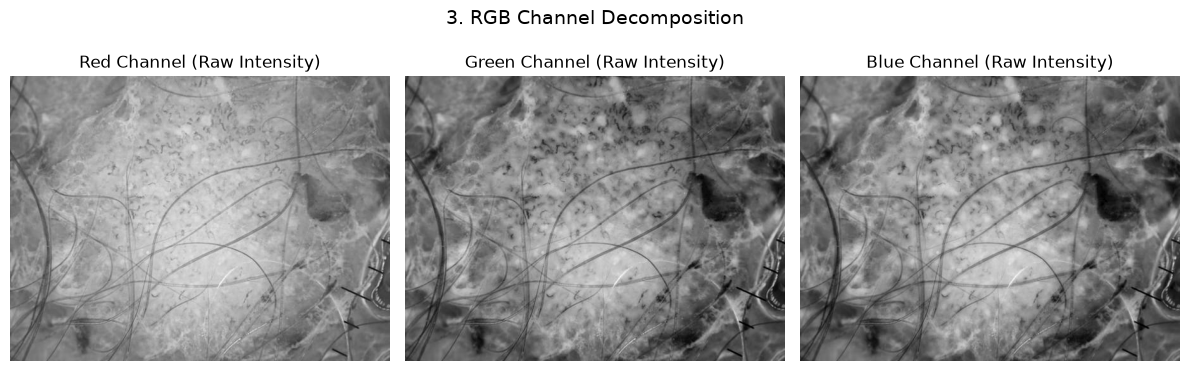

In [7]:
R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(R, cmap='gray'); axes[0].set_title("Red Channel (Raw Intensity)");   axes[0].axis('off')
axes[1].imshow(G, cmap='gray'); axes[1].set_title("Green Channel (Raw Intensity)"); axes[1].axis('off')
axes[2].imshow(B, cmap='gray'); axes[2].set_title("Blue Channel (Raw Intensity)");  axes[2].axis('off')
plt.suptitle("3. RGB Channel Decomposition", fontsize=14)
plt.tight_layout()
plt.show()

The Green Channel (or Blue Channel) is characterized by its ability to discern the lesion visually from the neighboring tissues:

The enhanced contrast enables a clearer definition of the lesion’s margins perhaps because less melanin and hemoglobin absorption leads to a darker appearance compared to the normal lighter tissues when using the Green and Blue channels.

In the Red Channel, both skin and red/pink lesions reflect light very brightly, thus providing a washed-out image with minimal difference in the brightness level between the lesion and the ordinary skin tissues.


=== 4. GRAYSCALE CONVERSION ===
Max pixel difference between Naive and Luminosity: 11.26


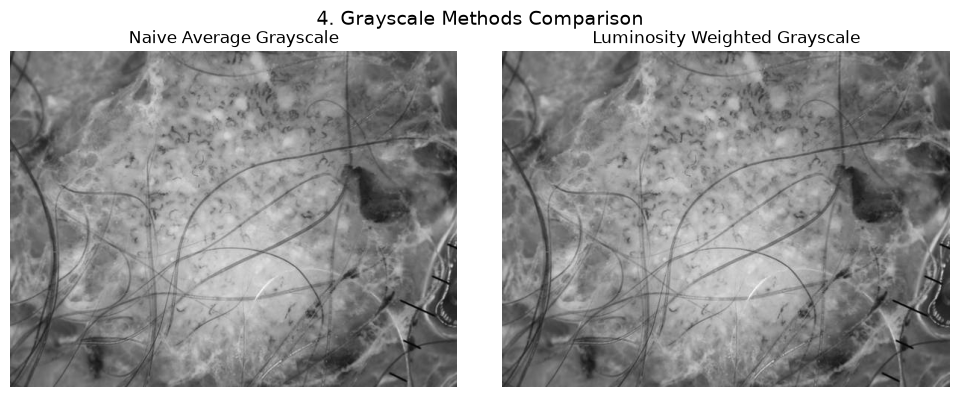

In [8]:
img_float = img.astype(np.float32)

# Naive Average: (R + G + B) / 3
gray_naive = np.mean(img_float, axis=2)

# Luminosity Weighted Formula: 0.299R + 0.587G + 0.114B
gray_luminosity = (0.299 * img_float[:, :, 0] + 
                   0.587 * img_float[:, :, 1] + 
                   0.114 * img_float[:, :, 2])

max_diff = np.max(np.abs(gray_naive - gray_luminosity))
print("\n=== 4. GRAYSCALE CONVERSION ===")
print(f"Max pixel difference between Naive and Luminosity: {max_diff:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray_naive, cmap='gray')
axes[0].set_title("Naive Average Grayscale")
axes[0].axis('off')

axes[1].imshow(gray_luminosity, cmap='gray')
axes[1].set_title("Luminosity Weighted Grayscale")
axes[1].axis('off')
plt.suptitle("4. Grayscale Methods Comparison", fontsize=14)
plt.tight_layout()
plt.show()

With a maximum pixel difference of 11.26, there is a significant numerical discrepancy amongst these two techniques in question.

Naive Average: This presumes that all three colors play an equal role in brightness identification (both channels Red, Green, & Blue are given equal importance 0.333R + 0.333G + 0.333B).
Luminosity-Weighted Formula: This method uses different values for the weights of the colors while giving priority to the Green channel compared to the other ones 0.299R + 0.587G + 0.114B.

As far as the luminosity-weighted formula goes, it fits well to the human eye. Human beings are particularly sensitive to green wavelengths. In contrast, the naive average method gives power to the blue channel, while the luminosity method works well and matches our human perception.

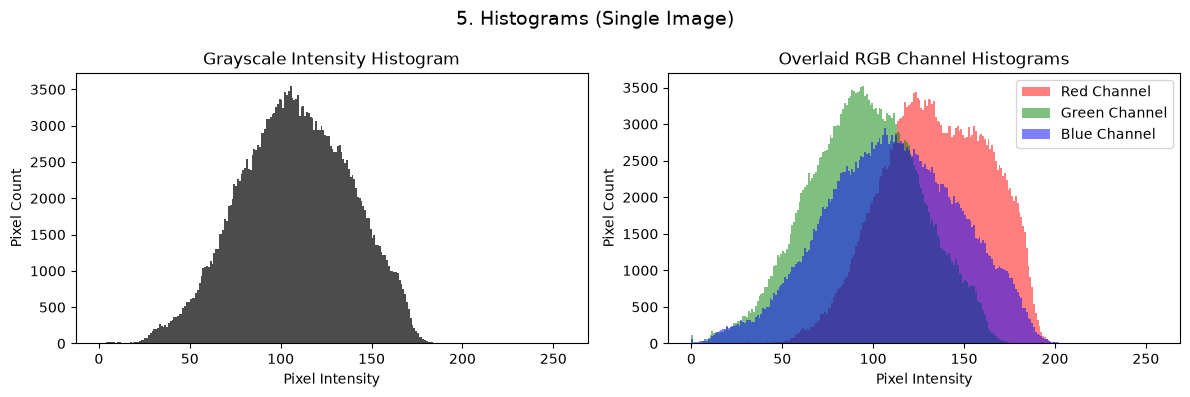

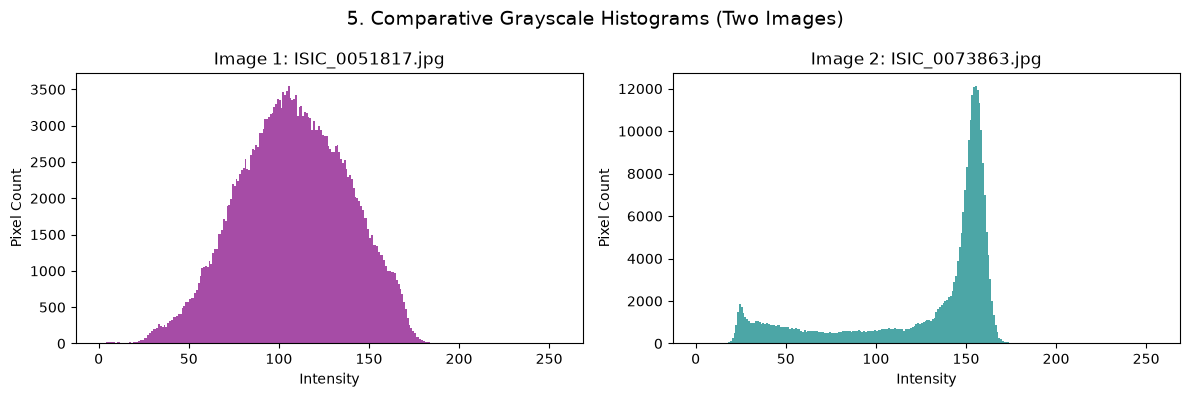

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gray_luminosity.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
axes[0].set_title("Grayscale Intensity Histogram")
axes[0].set_xlabel("Pixel Intensity"); axes[0].set_ylabel("Pixel Count")

colors = ('red', 'green', 'blue')
for i, col in enumerate(colors):
    axes[1].hist(img[:, :, i].ravel(), bins=256, range=(0, 256), color=col, alpha=0.5, label=f"{col.capitalize()} Channel")
axes[1].set_title("Overlaid RGB Channel Histograms")
axes[1].set_xlabel("Pixel Intensity"); axes[1].set_ylabel("Pixel Count")
axes[1].legend()

plt.suptitle("5. Histograms (Single Image)", fontsize=14)
plt.tight_layout()
plt.show()

second_file = all_images[1] if len(all_images) > 1 else all_images[0]
img2_path = os.path.join(images_dir, second_file)
img2_bgr = cv2.imread(img2_path)
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
gray2 = 0.299 * img2[:, :, 0] + 0.587 * img2[:, :, 1] + 0.114 * img2[:, :, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gray_luminosity.ravel(), bins=256, range=(0, 256), color='purple', alpha=0.7)
axes[0].set_title(f"Image 1: {selected_file}")
axes[0].set_xlabel("Intensity"); axes[0].set_ylabel("Pixel Count")

axes[1].hist(gray2.ravel(), bins=256, range=(0, 256), color='teal', alpha=0.7)
axes[1].set_title(f"Image 2: {second_file}")
axes[1].set_xlabel("Intensity"); axes[1].set_ylabel("Pixel Count")

plt.suptitle("5. Comparative Grayscale Histograms (Two Images)", fontsize=14)
plt.tight_layout()
plt.show()

Yes, the histogram in grayscale is a bell curved one while the histogram in RGB contains different peaks (Red the most elevated, Green the least elevated).Skin tone: Red light reflected raises the value of the value of the Red channel (120-190).Lesion dimension: Large area of a lesion means lower intensity values (30-100). Soft dermatoscopic illumination avoids the presence of mirror highlights, making the intensity values stick to 190.

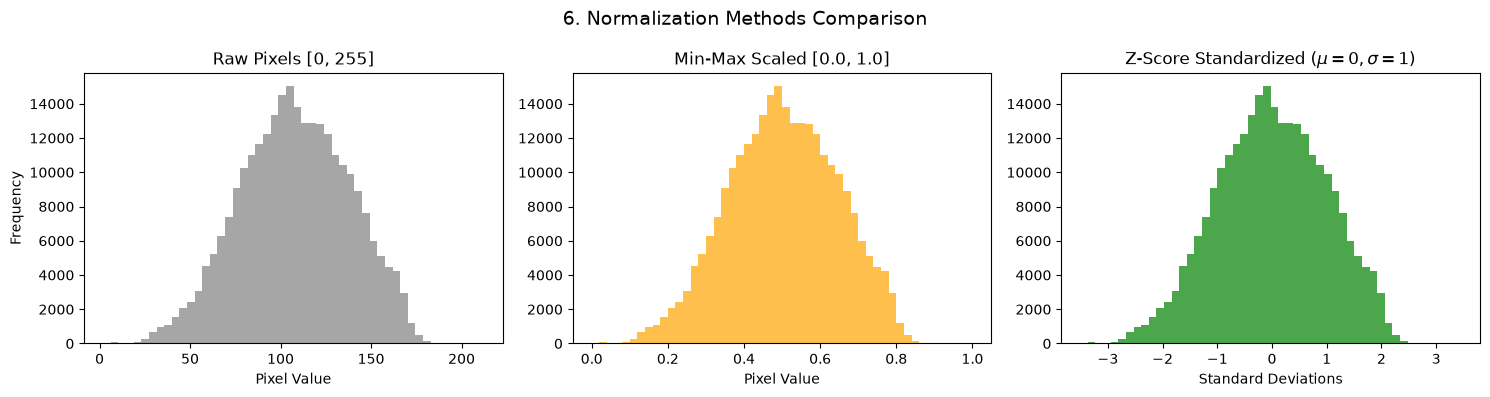

In [10]:
raw_pixels = gray_luminosity.ravel()

min_max_pixels = (gray_luminosity - gray_luminosity.min()) / (gray_luminosity.max() - gray_luminosity.min())
min_max_pixels = min_max_pixels.ravel()

z_score_pixels = (gray_luminosity - np.mean(gray_luminosity)) / np.std(gray_luminosity)
z_score_pixels = z_score_pixels.ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_pixels, bins=50, color='gray', alpha=0.7)
axes[0].set_title("Raw Pixels [0, 255]")
axes[0].set_xlabel("Pixel Value"); axes[0].set_ylabel("Frequency")

axes[1].hist(min_max_pixels, bins=50, color='orange', alpha=0.7)
axes[1].set_title("Min-Max Scaled [0.0, 1.0]")
axes[1].set_xlabel("Pixel Value")

axes[2].hist(z_score_pixels, bins=50, color='green', alpha=0.7)
axes[2].set_title("Z-Score Standardized ($\mu=0, \sigma=1$)")
axes[2].set_xlabel("Standard Deviations")

plt.suptitle("6. Normalization Methods Comparison", fontsize=14)
plt.tight_layout()
plt.show()

Normalization keeps input values on a small, consistent scale, allowing to prevent exploding gradients and allows gradient descent optimization in order to converge faster and in a more stable way.